<a href="https://colab.research.google.com/github/RRADJon/TEMPO/blob/main/Integrated_Boltz_PBPK_AOP_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#@title Simulation Input

#@markdown ### If generating parameters, enter SMILES
smiles_input = "CC(C)(C)[C@@H](C(=O)N[C@@H](CC1=CC=CC=C1)[C@H](CN(CC2=CC=C(C=C2)C3=CC=CC=N3)NC(=O)[C@H](C(C)(C)C)NC(=O)OC)O)NC(=O)OC" #@param {type:"string"}

#@markdown ### Virtual Patient
individual_weight = 75 #@param {type:"number"}
dose_mg_per_kg = 10 #@param {type:"number"}
route = "oral" #@param ["oral","iv"]
repeat_doses = True #@param {type:"boolean"}
dose_interval = 0 #@param {type:"number"}
simulation_time_hr = 200 #@param {type:"number"}

In [11]:
#@title Single Fu Predictor Boltz-2 + NN Ensemble (21s)
!pip install -q rdkit
import os, requests, base64, time, json, torch, torch.nn as nn, io
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Crippen
from pathlib import Path
from google.colab import userdata

# --- 1. CONFIGURATION & INPUT ---
LIGAND_SMILES = smiles_input
NVIDIA_API_KEY = userdata.get('NVIDIA_API_KEY')
PUBLIC_URL = "https://health.api.nvidia.com/v1/biology/mit/boltz2/predict"
HEADERS = {"Authorization": f"Bearer {NVIDIA_API_KEY}", "Content-Type": "application/json"}

# Protein Data
PROTEINS = [
    {"id": "Albumin", "pdb": "1Ao6", "seq": "MKWVTFISLLFLFSSAYSRGVFRRDAHKSEVAHRFKDLGEENFKALVLIAFAQYLQQCPFEDHVKLVNEVTEFAKTCVADESAENCDKSLHTLFGDKLCTVATLRETYGEMADCCAKQEPERNECFLQHKDDNPNLPRLVRPEVDVMCTAFHDNEETFLKKYLYEIARRHPYFYAPELLFFAKRYKAAFTECCQAADKAACLLPKLDELRDEGKASSAKQRLKCASLQKFGERAFKAWAVARLSQRFPKAEFAEVSKLVTDLTKVHTECCHGDLLECADDRADLAKYICENQDSISSKLKECCEKPLLEKSHCIAEVENDEMPADLPSLAADFVESKDVCKNYAEAKDVFLGMFLYEYARRHPDYSVVLLLRLAKTYETTLEKCCAAADPHECYAKVFDEFKPLVEEPQNLIKQNCELFEQLGEYKFQNALLVRYTKKVPQVSTPTLVEVSRNLGKVGSKCCKHPEAKRMPCAEDYLSVVLNQLCVLHEKTPVSDRVTKCCTESLVNRRPCFSALEVDETYVPKEFNAETFTFHADICTLSEKERQIKKQTALVELVKHKPKATKEQLKAVMDDFAAFVEKCCKADDKETCFAEEGKKLVAASQAALGL"},
    {"id": "AGP", "pdb": "3KQ0", "seq": "MALSWVLTVLSLLPLLEAQIPLCANLVPVPITNATLDRITGKWFYIASAFRNEEYNKSVQEIQATFFYFTPNKTEDTIFLREYQTRQDQCIYNTTYLNVQRENGTISRYVGGQEHFAHLLILRDTKTYMLAFDVNDEKNWGLSVYADKPETTKEQLGEFYEALDCLRIPKSDVVYTDWKKDKCEPLEKQHEKERKQEEGES"}
]

# --- 2. UTILITY FUNCTIONS ---
def get_physchem(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return 0.0, 0.0
    logP = Crippen.MolLogP(mol)
    fu_simple = np.clip(1 / (1 + (0.3 * 10**logP)), 0.001, 1.0)
    return logP, fu_simple

def get_template_b64(pdb_id):
    path = f"{pdb_id}.pdb"
    if not os.path.exists(path):
        r = requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb")
        with open(path, "wb") as f: f.write(r.content)
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def predict_boltz(protein_id, sequence, template_b64, smiles):
    payload = {
        "polymers": [{
            "id": "A", "sequence": sequence, "molecule_type": "protein",
            "templates": [{"pdb": template_b64, "chain_id": "A"}]
        }],
        "ligands": [{"id": "L1", "smiles": smiles, "predict_affinity": True}]
    }
    resp = requests.post(PUBLIC_URL, headers=HEADERS, json=payload)
    if resp.status_code == 429:
        time.sleep(2); return predict_boltz(protein_id, sequence, template_b64, smiles)
    if resp.status_code != 200: raise Exception(f"API Error: {resp.text}")
    data = resp.json()
    aff = data.get("affinity_predictions", data.get("affinities", {})).get("L1", {})
    return aff.get("affinity_pic50", [0.0])[0], aff.get("affinity_probability_binary", [0.0])[0]

# --- 3. MODEL ARCHITECTURE & LOADING ---
class BinderNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.LayerNorm(32), nn.LeakyReLU(),
            nn.Linear(32, 16), nn.LeakyReLU(), nn.Linear(16, 1)
        )
    def forward(self, x): return self.net(x)

def load_ensemble(num_features=5):
    # Full Base64 String with Correct Padding
    MODEL_B64 = "UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAWAAwAYmVzdF9mdV9tb2RlbC9kYXRhLnBrbEZCCABaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYCAAAADAud2VpZ2h0cQJjdG9yY2guX3V0aWxzCl9yZWJ1aWxkX3RlbnNvcl92MgpxAygoWAcAAABzdG9yYWdlcQRjdG9yY2gKRmxvYXRTdG9yYWdlCnEFWAEAAAAwcQZYAwAAAGNwdXEHS6B0cQhRSwBLIEsFhnEJSwVLAYZxColoAClScQt0cQxScQ1YBgAAADAuYmlhc3EOaAMoKGgEaAVYAQAAADFxD2gHSyB0cRBRSwBLIIVxEUsBhXESiWgAKVJxE3RxFFJxFVgIAAAAMS53ZWlnaHRxFmgDKChoBGgFWAEAAAAycRdoB0sgdHEYUUsASyCFcRlLAYVxGoloAClScRt0cRxScR1YBgAAADEuYmlhc3EeaAMoKGgEaAVYAQAAADNxH2gHSyB0cSBRSwBLIIVxIUsBhXEiiWgAKVJxI3RxJFJxJVgIAAAAMy53ZWlnaHRxJmgDKChoBGgFWAEAAAA0cSdoB00AAnRxKFFLAEsQSyCGcSlLIEsBhnEqiWgAKVJxK3RxLFJxLVgGAAAAMy5iaWFzcS5oAygoaARoBVgBAAAANXEvaAdLEHRxMFFLAEsQhXExSwGFcTKJaAApUnEzdHE0UnE1WAgAAAA1LndlaWdodHE2aAMoKGgEaAVYAQAAADZxN2gHSxB0cThRSwBLAUsQhnE5SxBLAYZxOoloAClScTt0cTxScT1YBgAAADUuYmlhc3E+aAMoKGgEaAVYAQAAADdxP2gHSwF0cUBRSwBLAYVxQUsBhXFCiWgAKVJxQ3RxRFJxRXV9cUZYCQAAAF9tZXRhZGF0YXFHaAApUnFIKFgAAAAAcUl9cUpYBwAAAHZlcnNpb25xS0sBc1gBAAAAMHFMfXFNaEtLAXNYAQAAADFxTn1xT2hLSwFzWAEAAAAycVB9cVFoS0sBc1gBAAAAM3FSfXFTaEtLAXNYAQAAADRxVH1xVWhLSwFzWAEAAAA1cVZ9cVdoS0sBc3VzYi5QSwcI0jgljgoDAAAKAwAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAdACsAYmVzdF9mdV9tb2RlbC8uZm9ybWF0X3ZlcnNpb25GQicAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMVBLBwi379yDAQAAAAEAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAACAAMQBiZXN0X2Z1X21vZGVsLy5zdG9yYWdlX2FsaWdubWVudEZCLQBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlo2NFBLBwg/d3HpAgAAAAIAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABcAOQBiZXN0X2Z1X21vZGVsL2J5dGVvcmRlckZCNQBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWmxpdHRsZVBLBwiFPeMZBgAAAAYAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABQAOABiZXN0X2Z1X21vZGVsL2RhdGEvMEZCNABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpajT4nvt8siT70j2k+r8SIvpLeYD56lp6+ie6FvungE79YeGI+jvj6vuQpvj2/eQM+BUKXPsdfkD115Q2+L8YVPlUyxz6BZvI+xmKVvjfM4T7osKI+RfSAvjiIwb7xR0w+ueT2vkevpz7fYjw+dt4gvr1GAj8cQNk99IiGPv1k2D5iI80+Qs3IvH+fJL/Q9KE+eadcvXWb4b5VdUK+WymiPc12rD4YeYQ+Q2Lmva1W3j0kYhU9SmEQPSkibz1iYLK+zNuvvfIQWz5S++G+kZ/AvjM3tLrhhbs96DpXvr2KU755YI2+iyypPhnhwD2GvwC/vNHKvp8Akb5VMd6+5ewrP+ubBr6X+dE9GkP/PaauR76u6LA+DEmAPWEwor5+Z3G9RhIQPzds8j1yT6u+YisgPkB1gj4x3yQ9aVyRvWf5M79hVyo81iF5vTr6fr62p5u+YYQsPhw/Ur18tR2+n91AvJ93B77pAPw+V1U9vZYz6bxqRYC+E1gBPu9cGj9ynom+2j8WvAjfRD6tvle+8IHjPR8Bnz66ANw9Mo7OPPMiQ76AxXa7GwELvmEr7j2ckti+suy2vjnZLT4DtbA+qlC9Por7mz2XCss+GDDMvke6wj2uCBI+J7WqvXYwjT1BRuW9XD5ovmQ2zD6nO3E+7IbAPou02b5Vb+w+cRAoP0CzDDzheoM9X4ebPlcHOr4ODs6+Zz22Pa+3jj5czie8vbOHPFAHnj6RTX8+PFiIvuWMwz0IFhq/AsaIvjN7QL44vkI+rkQvvlBZz72b5tI8hlRqvsP2ML1Hxke9tquoPTUBkD6Y5ke/krHQvQ4phj5GWwq/UDckv91Rab4CcEE+Yfo0vVBLBwhiUhcbgAIAAIACAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABQAPgBiZXN0X2Z1X21vZGVsL2RhdGEvMUZCOgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpa4iJSvJmcij722Rc9ep7XPW80bD4MGzW+jkjgvc7Pgj6i6Tm9e6Ynvv2Owzwo/HA+zn6FPlyX8Lzs4nw+n+4xPvDUZj1vRa4+hD6bPrA+k71YJ7o9f7hPvq6F4L6ss+s58ceZvgB3kL6/nZA9JQqBvfhPtD5NWy4+7e0wvuuF4T1QSwcI9jSGgIAAAACAAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAUAD4AYmVzdF9mdV9tb2RlbC9kYXRhLzJGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWpLykT9RUa4/dKOoP2xikT+D9bg/ur66PwAquj+1g7Q/ofmkP3ZU7T8iHvk/pKmlP3zQ0T+gW54/BdrOPxRp1z++MsQ/Inm9P6venz/aDZw/rA+oP8oK8j/+0uU/7QWmP36u6D+21L8/HEi/P7QHpD9DPNw/CjmQPwkw6z9dR+E/UEsHCL7/nAuAAAAAgAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAFAA+AGJlc3RfZnVfbW9kZWwvZGF0YS8zRkI6AFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlo71EQ+6YFUvfcqXz7qJJu9j36nPqBEaj6IexE+T8PJvRYJgD5x7A6+Tb7VvaMMXT5+M3w+rkMVPjVlbT4KkUM+4EFzvsR7gzxB1Oc9eOwEvp3UkT26wNO8t+yGPJ/Ukr71rTq+S91bPqeTCz7fY8C+5f0QPqB6Wj7z0I098hqbvVBLBwj3KauYgAAAAIAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABQAPgBiZXN0X2Z1X21vZGVsL2RhdGEvNEZCOgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpahvE2vhODaD43AzQ+FFucPaI0wL1UIEk+NIC1vX8/MT03aVc9inA4P6CUSrwTmAS+WlljvhAwLj5Wadg9TMjnPfZotzxLA+g9VcsYPp0lPL2/cIc8v1PjvgskHL7q/vA9sKVFPRwgdL5XTue9GnWePbg4YT3u2iU+UygZPvK1LL/fHr++K7RwPsqESb2IJgM+ue4yPir6hz4mDgS+Zpv5vk2MlD6yooE/cBlgP7ZVaT4zNjW+pxKnPlNykjwzNBk+5rfrPhC/27wlFqM+06CuvrXXa7zk7C+/yiLwvhC4Bz/gVwM/W39/vXB55bseqpY+D5U0vcVb8r0bopg+13wTvy/djbxoKPa9TiAEvSlepj0P7vu+sJyOvmEmyrz2dTI+kEgbPcI//b0s2jw+eEmFPSxfm7yzE+m9Qj2EvIN21jxi3Au+j3xiPXBkuTziF429vYmXPuUiB7+THKG+j4/YPTPXVD6l8J6+vc0qvutkSL5k+dG9dOw7vijV7z0C8nW91jqXvcYYWD62+ji++1lXPjtkLT6UHsI95MLvPfmazr3cSIs+jpEyPxQdZT86rMY9h0HOvbomZz6TLf48dTuuvAXFRj5yDgA8iUaCPnZfyj2kQCe+7QURvz6HZ77DZF89+ASqPtawhL70gwq+wBWSPrld971wclk93vp9PibwDr8BRfY+KDKPPswLlz5FoQk+dG4Cv0+DZb6eU48+0Q7EPsbem7xNEoG/IOYLvf/Sub4Cury+G7kGvUcoI74nVDc9IsjvvrnggL4CRgi/Go6bvirKCz9FFj4/Wx2NPitgyr6Nka0+Vg4YP8Pi0L3sGWS/bU0ZPuF21D6TrWy9M/EIPtgiiD0tXd+8vKt9vScjKL3Re3q9p45xvTb267yA07E9b6ubPfmtnj23FBS+eBQavrgBPb7GQZI9+mp/PeFqmb0BS7a9hroCvnzaIb4qheE9YNoVvpKzGr7y/JW8xSE9vANIK77BHB8+MiDBvOQ9GL6pAWc9a40ovguskz14ec28wxoZvOl4ND5Re7K9c3b2Pb63mzw8i3Y+mUOovG0wmL0j8Sg9cKEaP1k7XD/RTr69EECkvTXCiT1mcBa+dCT4PYPqgj0gPC8+yVCPPrBOXb7PmmC8XbDzvn3vB782RIg+mY5GPpaSBr469Ak98ymjPt0p4z2NONC9P7sDPs60CL+V+SA+kAt1PjTUDz47roK9zxervm992r4IWZo+bDoMvjH/Kb9FLMS+LCAXv/wzLL93g4s+R4UTPtKckj6JksG83lk8vtYiYb80mFm9m73LPomKHz5uhwm+4L1uPRsxRj3+Mnw+PM7yvQZYi78AsIq+uFeCPiGfKr3kVma/5n1YPiK8Jr3tSfY9eLPAPcEoQT4fpVk+9MeCPjlnv70Bg7O+RlA7PuwHiT54sCQ/aB6Mvf1llr1Ed8A9EK0jve5emT7KfZ89hVTwPTDRCTsI5oi+MsFmvkXXNL94T5i++SFPPTP20D4IC9a8LY8ZPqTlij7zOjo+0twSPQWgkTz7TPq+oai7PnW/mb4w9Jw+gdhcvoaXub6vRK2+iczcvarqRj6150K+fZ0wvy1IT7+N8Is9QnSZPveK3zxyk8Y+7Wb9vc/x0r2Cvz4+L8dDPgbwJT6UKDI+3cIvP0OT6j51SxC+CxEsPu77jz4pyzC8lifQvabTZT5jj9Q9wV6wvlLJtT4teAA+wUyhvkZPKL73T26+YrFnPr+cTL59Y74+ldjyPgUIsbty5Fa+qI3AvXEZxjswpAA/rDyUvYh27jyIaAM9ZTAgv72ozDznx3m86J/xvQw39D06LCO9q0+/PvgYjb1WdF+/KhzjPt30Hj3yes+9kPq4vqtXvD1nIM++L7LbPlsFlj60Ucq9G9s9vrt4zz7ecwm8r2gyv9Ovqj5fc2q9fQzsPUi5lT2eKwE/5+mnvrLOAb/zWQC/xpfxvau5iz6h5J0+cIJfvoPyXryp5Rw+iT8cvpnZar7D76y+nbgBPvXCBD6+eh8+w1Ocvq5x9z7GZ8K9PtIxvpwguz2ub5G+8KyRPjmO+74L7IY92yMHvo6CLb+ylpU+Vp8fP/7G+j4cIbi94mFhPXuVHj7aR9u988MlPx5qb710D2++YW2Kv58UgL+yPn69XqQKvZ83kz6j2M0+XzrXPdJfWz8QIBE9vnowvxVsyz7ml+s+17vYvRTGRL+UXTG/j8wpvmj6XT99c1E+NJ4FvgO8UT7JPro85m6mvpH7rjztRzw8eBj+Pb2gLb6OnZ++ESIfvry+U7zjnrQ927wRuxgxCT6bA0g8gap1vpy3ET74cuU95DO9Pe+pRj5p1cU+5PVqPrkI/DyLsjA+2XT5PVSrcj6TUZm+nDAHvuK+frwpj7S9E/LWPhf6jT6bfeQ8oOIjvKNeDT3MMBS+lSo8vsUCXz5Cn4I+HYTmve9/dL8Ry0i/4/x/vHHq4z5yNQu7cMt+PobSRz0+8QG+ix6nvV/fi70Du4k+e3V3PlP4GD/kAaQ+952KvUSiuL4vpqU+4L55vXkGhb7fPoW9vQCJPR4mx73FX/A+wdyDvZDnHD1iHiW/3xm9vS8HjD093/O9Dp/hPpcQWT5cDKc+kXOgvK+nvD7BuYc9CoUxv2dkVr3xsEq/myOoPsP/xb3bLKC+fYYzvm5XGL0ryig+IzLdvkP6hD4Sa528dPgRvoIPGz/HAJe+x2AYvsI5Sb4ds9E9yjCGvsp2Lj1QSwcIcZhywwAIAAAACAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAUAD4AYmVzdF9mdV9tb2RlbC9kYXRhLzVGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWqVtHz5Avg0+uqYHPu6OAz6ydc4+lQG/PQx0jT3jdnW9JVUtPd0a1L0T7Kw911SSvs8gCr6cyYo9nVuVvSR0Qr1QSwcI4Tb/w0AAAABAAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAUAD4AYmVzdF9mdV9tb2RlbC9kYXRhLzZGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWqSxZr4PDhS/jhQ6v6Rnl77DS/s+qSEqPt/Z9745oYY/9Iz4vhzwiD7TTDo/Ib86v68bhD9g78I+Vh0tPrGeIT9QSwcIDrfazEAAAABAAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAUAD4AYmVzdF9mdV9tb2RlbC9kYXRhLzdGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWphfMz5QSwcIQQdaCwQAAAAEAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAVADkAYmVzdF9mdV9tb2RlbC92ZXJzaW9uRkI1AFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMwpQSwcI0Z5nVQIAAAACAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAkACwAYmVzdF9mdV9tb2RlbC8uZGF0YS9zZXJpYWxpemF0aW9uX2lkRkIoAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlowODI2ODY0NzczNTYwNDU3NzcwMDE4MjkxOTc0MDg5ODI4MjAyMDI4UEsHCL6jwaUoAAAAKAAAAFBLAQIAAAAACAgAAAAAAADSOCWOCgMAAAoDAAAWAAAAAAAAAAAAAAAAAAAAAABiZXN0X2Z1X21vZGVsL2RhdGEucGtsUEsBAgAAAAAICAAAAAAAALfv3IMBAAAAAQAAAB0AAAAAAAAAAAAAAAAAWgMAAGJlc3RfZnVfbW9kZWwvLmZvcm1hdF92ZXJzaW9uUEsBAgAAAAAICAAAAAAAAD93cekCAAAAAgAAACAAAAAAAAAAAAAAAAAA0QMAAGJlc3RfZnVfbW9kZWwvLnN0b3JhZ2VfYWxpZ25tZW50UEsBAgAAAAAICAAAAAAAAIU94xkGAAAABgAAABcAAAAAAAAAAAAAAAAAUgQAAGJlc3RfZnVfbW9kZWwvYnl0ZW9yZGVyUEsBAgAAAAAICAAAAAAAAGJSFxuAAgAAgAIAABQAAAAAAAAAAAAAAAAA1gQAAGJlc3RfZnVfbW9kZWwvZGF0YS8wUEsBAgAAAAAICAAAAAAAAPY0hoCAAAAAgAAAABQAAAAAAAAAAAAAAAAA0AcAAGJlc3RfZnVfbW9kZWwvZGF0YS8xUEsBAgAAAAAICAAAAAAAAL7/nAuAAAAAgAAAABQAAAAAAAAAAAAAAAAA0AgAAGJlc3RfZnVfbW9kZWwvZGF0YS8yUEsBAgAAAAAICAAAAAAAAPcpq5iAAAAAgAAAABQAAAAAAAAAAAAAAAAA0AkAAGJlc3RfZnVfbW9kZWwvZGF0YS8zUEsBAgAAAAAICAAAAAAAAHGYcsMACAAAAAgAABQAAAAAAAAAAAAAAAAA0AoAAGJlc3RfZnVfbW9kZWwvZGF0YS80UEsBAgAAAAAICAAAAAAAAOE2/8NAAAAAQAAAABQAAAAAAAAAAAAAAAAAUBMAAGJlc3RfZnVfbW9kZWwvZGF0YS81UEsBAgAAAAAICAAAAAAAAA632sxAAAAAQAAAABQAAAAAAAAAAAAAAAAAEBQAAGJlc3RfZnVfbW9kZWwvZGF0YS82UEsBAgAAAAAICAAAAAAAAEEHWgsEAAAABAAAABQAAAAAAAAAAAAAAAAA0BQAAGJlc3RfZnVfbW9kZWwvZGF0YS83UEsBAgAAAAAICAAAAAAAANGeZ1UCAAAAAgAAABUAAAAAAAAAAAAAAAAAVBUAAGJlc3RfZnVfbW9kZWwvdmVyc2lvblBLAQIAAAAACAgAAAAAAAC+o8GlKAAAACgAAAAkAAAAAAAAAAAAAAAAANIVAABiZXN0X2Z1X21vZGVsLy5kYXRhL3NlcmlhbGl6YXRpb25faWRQSwYGLAAAAAAAAAAeAy0AAAAAAAAAAAAOAAAAAAAAAA4AAAAAAAAAxwMAAAAAAAB4FgAAAAAAAFBLBgcAAAAAPxoAAAAAAAABAAAAUEsFBgAAAAAOAA4AxwMAAHgWAAAAAA=="

    model_bytes = base64.b64decode(MODEL_B64 + "===") # Added safety padding
    buffer = io.BytesIO(model_bytes)
    model = BinderNet(num_features)
    state_dict = torch.load(buffer, map_location=torch.device('cpu'))

    first_key = list(state_dict.keys())[0]
    if not first_key.startswith("net."):
        model.net.load_state_dict(state_dict)
    else:
        model.load_state_dict(state_dict)
    model.eval()
    return model

# --- 4. THE PIPELINE ---
print(f"Starting PBPK Pipeline for: {LIGAND_SMILES[:30]}...")

logP, fu_simple = get_physchem(LIGAND_SMILES)
print(f"Calculated LogP: {logP:.2f}, Simple Fu: {fu_simple:.4f}")

results = {"logP": logP, "fu_simple": fu_simple}
for p in PROTEINS:
    print(f"Running Boltz-2 against {p['id']}...")
    b64 = get_template_b64(p['pdb'])
    pic50, prob = predict_boltz(p['id'], p['seq'], b64, LIGAND_SMILES)
    results[f"{p['id']}_pic50"] = pic50
    results[f"{p['id']}_prob"] = prob
    print(f"{p['id']} pIC50: {pic50:.2f}")

# Step 3: Ensemble Prediction & Calibration
features = ['logP', 'fu_simple', 'Albumin_pic50', 'Albumin_prob', 'AGP_pic50']
X_input = np.array([[results[f] for f in features]])

# Clipping inputs as per training (5th/95th percentiles)
X_input[:, 0] = np.clip(X_input[:, 0], -1.0, 6.5) # logP
X_input[:, 1] = np.clip(X_input[:, 1], 0.001, 1.0) # fu_simple

try:
    model = load_ensemble(num_features=len(features))
    X_tensor = torch.tensor(X_input, dtype=torch.float32)

    with torch.no_grad():
        # Predict in scaled log-space
        log_pred = model(X_tensor).item()
        # Inverse: y_trans = -np.log10(y_raw + 1e-5)
        raw_p = 10**(-log_pred) - 1e-5
        avg_p = np.clip(raw_p, 0, 1)

        # Power Calibration from training
        if avg_p > 0.5:
            final_fu = avg_p**0.8
        else:
            final_fu = avg_p**1.2

    final_fu = np.clip(final_fu, 0, 1)
    results["Predicted_fu"] = final_fu

    print(f"\n{'='*40}\nFINAL CALIBRATED PREDICTION (fu): {final_fu:.4f}\n{'='*40}")
    display(pd.DataFrame([results]))

except Exception as e:
    print(f"\n Prediction Failed: {e}")

Starting PBPK Pipeline for: CC(C)(C)[C@@H](C(=O)N[C@@H](CC...
Calculated LogP: 4.21, Simple Fu: 0.0010
Running Boltz-2 against Albumin...
Albumin pIC50: 7.72
Running Boltz-2 against AGP...
AGP pIC50: 8.75

FINAL CALIBRATED PREDICTION (fu): 0.0311


,logP,fu_simple,Albumin_pic50,Albumin_prob,AGP_pic50,AGP_prob,Predicted_fu
0,4.2116,0.001,7.715125,0.570312,8.754109,0.621094,0.031103


In [12]:
# @title Boltz-2 + NN filter (150s)
ligand = smiles_input

!pip install -q biopython httpx rdkit

import json, io, os, torch, base64, time, requests
import numpy as np
import pandas as pd
import torch.nn as nn
from pathlib import Path
from Bio.PDB.MMCIFParser import MMCIFParser
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from google.colab import userdata
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- CONFIGURATION ---
NVIDIA_API_KEY = userdata.get('NVIDIA_API_KEY')
PUBLIC_URL = "https://health.api.nvidia.com/v1/biology/mit/boltz2/predict"
MODEL_B64 = """..."""
HEADERS = {"Authorization": f"Bearer {NVIDIA_API_KEY}", "Content-Type": "application/json"}

# --- 1. NEURAL NETWORK ARCHITECTURE ---
class BinderNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# --- 2. PHYSICS & FEATURE EXTRACTION ---
parser = MMCIFParser(QUIET=True)

def extract_features_from_result(result_json):
    try:
        aff_root = result_json.get("affinity_predictions", result_json.get("affinities", {}))
        lig_aff = aff_root.get("L1", {})
        pic50 = lig_aff.get("affinity_pic50", [0.0])[0]
        prob = lig_aff.get("affinity_probability_binary", [0.0])[0]
        conf = np.mean(result_json.get("confidence_scores", [0.0]))

        cif_string = result_json["structures"][0]["structure"]
        structure = parser.get_structure("complex", io.StringIO(cif_string))
        p_coords = [a.get_coord() for a in structure.get_atoms() if len(a.get_parent().get_resname()) <= 3]
        l_coords = [a.get_coord() for a in structure.get_atoms() if len(a.get_parent().get_resname()) > 3 or a.get_parent().get_resname() == "LIG1"]

        if not p_coords or not l_coords: return None
        dists = cdist(np.array(p_coords), np.array(l_coords))

        bins = [np.sum((dists >= b[0]) & (dists < b[1])) for b in [(0, 2.5), (2.5, 3.5), (3.5, 4.5), (4.5, 6.0)]]
        clashes = np.sum(dists < 1.9)
        num_contacts = np.sum(dists < 4.5)

        return {
            "boltz_pic50": pic50, "boltz_prob": prob, "confidence": conf,
            "bin_0_2.5": bins[0], "bin_2.5_3.5": bins[1], "bin_3.5_4.5": bins[2], "bin_4.5_6.0": bins[3],
            "num_contacts": num_contacts, "clash_count": clashes
        }
    except Exception as e:
        print(f"Feature Extraction Error: {e}")
        return None

# --- 3. UTILITIES ---
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        r = requests.get(url)
        with open(filename, "wb") as f: f.write(r.content)
    return filename

def load_pdb_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def predict_structure(protein_id, sequence, ligand_smiles, template_b64=None):
    request_body = {
        "polymers": [{
            "id": "A", "sequence": sequence, "molecule_type": "protein",
            "templates": [{"pdb": template_b64, "chain_id": "A"}] if template_b64 else [],
            "msa": {"uniref90": {"a3m": {"alignment": f">seq\n{sequence}", "format": "a3m"}}}
        }],
        "ligands": [{"id": "L1", "smiles": ligand_smiles, "predict_affinity": True}],
        "sampling_steps": 50, "diffusion_samples": 3
    }
    response = requests.post(PUBLIC_URL, headers=HEADERS, json=request_body)
    if response.status_code == 429:
        time.sleep(1)
        return predict_structure(protein_id, sequence, ligand_smiles, template_b64)
    return response.json()
# Prepare templates
protein_sequences = [
    {
        "id": "PolH",
        "sequence": "MATGQDRVVALVDMDCFFVQVEQRQNPHLRNKPCAVVQYKSWKGGGIIAVSYEARAFGVTRSMWADDAKKLCPDLLLAQVRESRGKANLTKYREASVEVMEIMSRFAVIERASIDEAYVDLTSAVQERLQKLQGQPISADLLPSTYIEGLPQGPTTAEETVQKEGMRKQGLFQWLDSLQIDNLTSPDLQLTVGAVIVEEMRAAIERETGFQCSAGISHNKVLAKLACGLNKPNRQTLVSHGSVPQLFSQMPIRKIRSLGGKLGASVIEILGIEYMGELTQFTESQLQSHFGEKNGSWLYAMCRGIEHDPVKPRQLPKTIGCSKNFPGKTALATREQVQWWLLQLAQELEERLTKDRNDNDRVATQLVVSIRVQGDKRLSSLRRCCALTRYDAHKMSHDAFTVIKNCNTSGIQTEWSPPLTMLFLCATKFSASAPSSSTDITSFLSSDPSSLPKVPVTSSEAKTQGSGPAVTATKKATTSLESFFQKAAERQKVKEASLSSLTAPTQAPMSNSPSKPSLPFQTSQSTGTEPFFKQKSLLLKQKQLNNSSVSSPQQNPWSNCKALPNSLPTEYPGCVPVCEGVSKLEESSKATPAEMDLAHNSQSMHASSASKSVLEVTQKATPNPSLLAAEDQVPCEKCGSLVPVWDMPEHMDYHFALELQKSFLQPHSSNPQVVSAVSHQGKRNPKSPLACTNKRPRPEGMQTLESFFKPLTH"
    },
    {
        "id": "NFE2L2",
        "sequence": "MMDLELPPPGLPSQQDMDLIDILWRQDIDLGVSREVFDFSQRRKEYELEKQKKLEKERQEQLQKEQEKAFFAQLQLDEETGEFLPIQPAQHIQSETSGSANYSQVAHIPKSDALYFDDCMQLLAQTFPFVDDNEVSSATFQSLVPDIPGHIESPVFIATNQAQSPETSVAQVAPVDLDGMQQDIEQVWEELLSIPELQCLNIENDKLVETTMVPSPEAKLTEVDNYHFYSSIPSMEKEVGNCSPHFLNAFEDSFSSILSTEDPNQLTVNSLNSDATVNTDFGDEFYSAFIAEPSISNSMPSPATLSHSLSELLNGPIDVSDLSLCKAFNQNHPESTAEFNDSDSGISLNTSPSVASPEHSVESSSYGDTLLGLSDSEVEELDSAPGSVKQNGPKTPVHSSGDMVQPLSPSQGQSTHVHDAQCENTPEKELPVSPGHRKTPFTKDKHSSRLEAHLTRDELRAKALHIPFPVEKIINLPVVDFNEMMSKEQFNEAQLALIRDIRRRGKNKVAAQNCRKRKLENIVELEQDLDHLKDEKEKLLKEKGENDKSLHLLKKQLSTLYLEVFSMLRDEDGKPYSPSEYSLQQTRDGNVFLVPKSKKPDVKKN"
    },
    {
        "id": "PolB",
        "sequence": "MSKRKAPQETLNGGITDMLTELANFEKNVSQAIHKYNAYRKAASVIAKYPHKIKSGAEAKKLPGVGTKIAEKIDEFLATGKLRKLEKIRQDDTSSSINFLTRVSGIGPSAARKFVDEGIKTLEDLRKNEDKLNHHQRIGLKYFGDFEKRIPREEMLQMQDIVLNEVKKVDSEYIATVCGSFRRGAESSGDMDVLLTHPSFTSESTKQPKLLHQVVEQLQKVHFITDTLSKGETKFMGVCQLPSKNDEKEYPHRRIDIRLIPKDQYYCGVLYFTGSDIFNKNMRAHALEKGFTINEYTIRPLGVTGVAGEPLPVDSEKDIFDYIQWKYREPKDRSE"
    },
    {
        "id": "APEX1",
        "sequence": "MPKRGKKGAVAEDGDELRTEPEAKKSKTAAKKNDKEAAGEGPALYEDPPDQKTSPSGKPATLKICSWNVDGLRAWIKKKGLDWVKEEAPDILCLQETKCSENKLPAELQELPGLSHQYWSAPSDKEGYSGVGLLSRQCPLKVSYGIGDEEHDQEGRVIVAEFDSFVLVTAYVPNAGRGLVRLEYRQRWDEAFRKFLKGLASRKPLVLCGDLNVAHEEIDLRNPKGNKKNAGFTPQERQGFGELLQAVPLADSFRHLYPNTPYAYTFWTYMMNARSKNVGWRLDYFLLSHSLLPALCDSKIRSKALGSDHCPITLYLAL"
    },
    {
        "id": "TDP1",
        "sequence": "MAKDAGLIEANGELKVFIDQNLSPGKGVVSLVAVHPSTVNPLGKQLLPKTFGQSNVNIAQQVVIGTPQRPAASNTLVVGSPHTPSTHFASQNQPSDSSPWSAGKRNRKGEKNGKGLRHFSMKVCEKVQRKGTTSYNEVADELVAEFSAADNHILPNESAYDQKNIRRRVYDALNVLMAMNIISKEKKEIKWIGLPTNSAQECQNLEVERQRRLERIKQKQSQLQELILQQIAFKNLVQRNRHAEQQASRPPPPNSVIHLPFIIVNTSKKTVIDCSISNDKFEYLFNFDNTFEIHDDIEVLKRMGMACGLESGSCSAEDLKMARSLVPKALEPYVTEMAQGTVGGVFITTAGSTSNGTRFSASDLTNGADGMLATSSNGSQYSGSRVETPVSYVGEDDEEDDDFNENDEDD"
    },
    {
        "id": "KDM4E",
        "sequence": "MKSVHSSPQNTSHTIMTFYPTMEEFADFNTYVAYMESQGAHQAGLAKVIPPKEWKARQMYDDIEDILIATPLQQVTSGQGGVFTQYHKKKKAMRVGQYRRLANSKKYQTPPHQNFADLEQRYWKSHPGNPPIYGADISGSLFEESTKQWNLGHLGTILDLLEQECGVVIEGVNTPYLYFGMWKTTFAWHTEDMDLYSINYLHFGEPKTWYVVPPEHGQHLERLARELFPDISRGCEAFLRHKVALISPTVLKENGIPFNCMTQEAGEFMVTFPYGYHAGFNHGFNCAEAINFATPRWIDYGKMASQCSCGESTVTFSMDPFVRIVQPESYELWKHRQDLAIVEHTEPRVAESQELSNWRDDIVLRRAALGLRLLPNLTAQCPTQPVSSGHCYNPKGCGTDAVPGSAFQSSAYHTQTQSLTLGMSARVLLPSTGSWGSGRGRGRGQGQGRGCSRGRGHGCCTRELGTEEPTVQPASKRRLLMGTRSRAQGHRPQLPLANDLMTNLSL"
    },
    {
        "id": "CYP2D6",
        "sequence": "MGLEALVPLAVIVAIFLLLVDLMHRRQRWAARYPPGPLPLPGLGNLLHVDFQNTPYCFDQLRRRFGDVFSLQLAWTPVVVLNGLAAVREALVTHGEDTADRPPVPITQILGFGPRSQGVFLARYGPAWREQRRFSVSTLRNLGLGKKSLEQWVTEEAACLCAAFANHSGRPFRPNGLLDKAVSNVIASLTCGRRFEYDDPRFLRLLDLAQEGLKEESGFLREVLNAVPVLLHIPALAGKVLRFQKAFLTQLDELLTEHRMTWDPAQPPRDLTEAFLAEMEKAKGNPESSFNDENLRIVVADLFSAGMVTTSTTLAWGLLLMILHPDVQRRVQQEIDDVIGQVRRPEMGDQAHMPYTTAVIHEVQRFGDIVPLGVTHMTSRDIEVQGFRIPKGTTLITNLSSVLKDEAVWEKPFRFHPEHFLDAQGHFVKPEAFLPFSAGRRACLGEPLARMELFLFFTSLLQHFSFSVPTGQPRPSHHGVFAFLVSPSPYELCAVPR"
    },
    {
        "id": "CYP3A4",
        "sequence": "MALIPDLAMETWLLLAVSLVLLYLYGTHSHGLFKKLGIPGPTPLPFLGNILSYHKGFCMFDMECHKKYGKVWGFYDGQQPVLAITDPDMIKTVLVKECYSVFTNRRPFGPVGFMKSAISIAEDEEWKRLRSLLSPTFTSGKLKEMVPIIAQYGDVLVRNLRREAETGKPVTLKDVFGAYSMDVITSTSFGVNIDSLNNPQDPFVENTKKLLRFDFLDPFFLSITVFPFLIPILEVLNICVFPREVTNFLRKSVKRMKESRLEDTQKHRVDFLQLMIDSQNSKETESHKALSDLELVAQSIIFIFAGYETTSSVLSFIMYELATHPDVQQKLQEEIDAVLPNKAPPTYDTVLQMEYLDMVVNETLRLFPIAMRLERVCKKDVEINGMFIPKGVVVMIPSYALHRDPKYWTEPEKFLPERFSKKNKDNIDPYIYTPFGSGPRNCIGMRFALMNMKLALIRVLQNFSFKPCKETQIPLKLSLGGLLQPEKPVVLKVESRDGTVSGA"
    },
    {
        "id": "ALDOA",
        "sequence": "MPYQYPALTPEQKKELSDIAHRIVAPGKGILAADESTGSIAKRLQSIGTENTEENRRFYRQLLLTADDRVNPCIGGVILFHETLYQKADDGRPFPQVIKSKGGVVGIKVDKGVVPLAGTNGETTTQGLDGLSERCAQYKKDGADFAKWRCVLKIGEHTPSALAIMENANVLARYASICQQNGIVPIVEPEILPDGDHDLKRCQYVTEKVLAAVYKALSDHHIYLEGTLLKPNMVTPGHACTQKFSHEEIAMATVTALRRTVPPAVTGITFLSGGQSEEEASINLNAINKCPLLKPWALTFSYGRALQASALKAWGGKKENLKAAQEEYVKRALANSLACQGKYTPSGQAGAAASESLFVSNHAY"
    },
    {
        "id": "KDM4A",
        "sequence": "MASESETLNPSARIMTFYPTMEEFRNFSRYIAYIESQGAHRAGLAKVVPPKEWKPRASYDDIDDLVIPAPIQQLVTGQSGLFTQYNIQKKAMTVREFRKIANSDKYCTPRYSEFEELERKYWKNLTFNPPIYGADVNGTLYEKHVDEWNIGRLRTILDLVEKESGITIEGVNTPYLYFGMWKTSFAWHTEDMDLYSINYLHFGEPKSWYSVPPEHGKRLERLAKGFFPGSAQSCEAFLRHKMTLISPLMLKKYGIPFDKVTQEAGEFMITFPYGYHAGFNHGFNCAESTNFATRRWIEYGKQAVLCSCRKDMVKISMDVFVRKFQPERYKLWKAGKDNTVIDHTLPTPEAAEFLKESELPPRAGNEEECPEEDMEGVEDGEEGDLKTSLAKHRIGTKRHRVCLEIPQEVSQSELFPKEDLSSEQYEMTECPAALAPVRPTHSSVRQVEDGLTFPDYSDSTEVKFEELKNVKLEEEDEEEEQAAAALDLSVNPASVGGRLVFSGSKKKSSSSLGSGSSRDSISSDSETSEPLSCRAQGQTGVLTVHSYAKGDGRVTVGEPCTRKKGSAARSFSERELAEVADEYMFSLEENKKSKGRRQPLSKLPRHHPLVLQECVSDDETSEQLTPEEEAEETEAWAKPLSQLWQNRPPNFEAEKEFNETMAQQAPHCAVCMIFQTYHQVEFGGFNQNCGNASDLAPQKQRTKPLIPEMCFTSTGCSTDINLSTPYLEEDGTSILVSCKKCSVRVHASCYGVPPAKASEDWMCSRCSANALEEDCCLCSLRGGALQRANDDRWVHVSCAVAILEARFVNIAERSPVDVSKIPLPRFKLKCIFCKKRRKRTAGCCVQCSHGRCPTAFHVSCAQAAGVMMQPDDWPFVVFITCFRHKIPNLERAKGALQSITAGQKVISKHKNGRFYQCEVVRLTTETFYEVNFDDGSFSDNLYPEDIVSQDCLQFGPPAEGEVVQVRWTDGQVYGAKFVASHPIQMYQVEFEDGSQLVVKRDDVYTLDEELPKRVKSRLSVASDMRFNEIFTEKEVKQEKKRQRVINSRYREDYIEPALYRAIME"
    }
]

template_pdb_map = {
    # AOP proteins
    "PolH": "3MR3",
    "NFE2L2": "2FLU",
    "PolB": "1BPX",
    "APEX1": "1BIX",
    "TDP1": "2AZE",
    "KDM4E": "2W2I",
    "CYP2D6": "2F9Q",
    "CYP3A4": "1TQN",
    "ALDOA": "1ALD",
    "KDM4A": "2GF7"
}
template_b64_map = {p_id: load_pdb_base64(download_pdb(pdb)) for p_id, pdb in template_pdb_map.items()}

output_dir = Path("boltz2_batch_outputs")
output_dir.mkdir(exist_ok=True)

all_features = []
for protein in protein_sequences:
    p_id = protein["id"]
    print(f"Processing: {p_id}")
    try:
        # Get raw result from API
        raw_result = predict_structure(p_id, protein["sequence"], ligand, template_b64_map.get(p_id))

        # --- NEW: SAVE RAW JSON TO DISK ---
        # This is what the visualizer is looking for
        json_path = output_dir / f"{p_id}.json"
        with open(json_path, "w") as f:
            json.dump(raw_result, f)

        # Extract features for the NN
        feats = extract_features_from_result(raw_result)
        if feats:
            feats["id"] = p_id
            all_features.append(feats)
            print(f"Success: pIC50={feats['boltz_pic50']:.2f} (Saved to {json_path})")

    except Exception as e:
        print(f"Failed {p_id}: {e}")

# --- 5. NN FILTERING & BINARY CLASSIFICATION ---
def process_features(df, smiles):
    mol = Chem.MolFromSmiles(smiles)
    lig_desc = {
        "mol_wt": Descriptors.MolWt(mol) if mol else 0,
        "logp": Descriptors.MolLogP(mol) if mol else 0,
        "h_donors": Descriptors.NumHDonors(mol) if mol else 0,
        "h_acceptors": Descriptors.NumHAcceptors(mol) if mol else 0,
        "tpsa": Descriptors.TPSA(mol) if mol else 0,
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol) if mol else 0,
    }

    # Feature Mapping
    df["contact_bin_0_2.5"] = df["bin_0_2.5"]
    df["contact_bin_2.5_3.5"] = df["bin_2.5_3.5"]
    df["contact_bin_3.5_4.5"] = df["bin_3.5_4.5"]
    df["contact_bin_4.5_6"] = df["bin_4.5_6.0"]
    df["strong_contacts"] = df["bin_0_2.5"]
    df["weak_contacts"] = df["bin_2.5_3.5"]
    df["contact_density"] = df["num_contacts"] / (df["confidence"] + 1e-6)
    df["affinity_contact_ratio"] = df["boltz_pic50"] * df["confidence"]
    for k, v in lig_desc.items(): df[k] = v

    base_features = [
        "boltz_pic50", "boltz_prob", "confidence",
        "contact_bin_0_2.5", "contact_bin_2.5_3.5", "contact_bin_3.5_4.5", "contact_bin_4.5_6",
        "strong_contacts", "weak_contacts", "contact_density", "affinity_contact_ratio",
        "mol_wt", "logp", "h_donors", "h_acceptors", "tpsa", "rotatable_bonds"
    ]

    X_raw = df[base_features].values
    log_indices = [3, 4, 5, 6, 7, 8, 9, 10, 11, 15]
    X_raw[:, log_indices] = np.log1p(np.maximum(X_raw[:, log_indices], 0))

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_inter = poly.fit_transform(X_raw)
    return StandardScaler().fit_transform(X_inter)

# Clean the string (remove any accidental whitespace/newlines from pasting)
MODEL_B64 = "".join(MODEL_B64.split())

# Apply padding fix
missing_padding = len(MODEL_B64) % 4
if missing_padding:
    MODEL_B64 += "=" * (4 - missing_padding)

try:
    print("Decoding model weights...")
    model_bytes = base64.b64decode(MODEL_B64)
    buffer = io.BytesIO(model_bytes)

    # Initialize Model
    model = BinderNet(input_dim=153)

    # Load state dict
    state_dict = torch.load(buffer, map_location=torch.device('cpu'))

    # Handle both direct state_dicts and nested 'model_state_dict' (common in checkpoints)
    if 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
    else:
        model.load_state_dict(state_dict)

    model.eval()
    print("Model loaded successfully.")

    if all_features:
        inference_df = pd.DataFrame(all_features)
        X_scaled = process_features(inference_df, ligand)

        with torch.no_grad():
            X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
            probs = model(X_tensor).numpy().flatten()

            inference_df["nn_score"] = probs
            inference_df["is_hit"] = (probs >= 0.5).astype(int)

        print(f"\nFound {inference_df['is_hit'].sum()} Predicted Binders.")
        display(inference_df[['id', 'boltz_pic50', 'clash_count', 'nn_score', 'is_hit']].sort_values("nn_score", ascending=False))
    else:
        print("No features extracted from Boltz-2 results. Cannot run NN inference.")

except Exception as e:
    print(f"Model Loading Error: {e}")
    print("\nTroubleshooting Tip: If you see 'Central Directory' errors, the string is still missing characters at the end.")

Processing: PolH
Success: pIC50=8.30 (Saved to boltz2_batch_outputs/PolH.json)
Processing: NFE2L2
Success: pIC50=7.57 (Saved to boltz2_batch_outputs/NFE2L2.json)
Processing: PolB
Success: pIC50=8.02 (Saved to boltz2_batch_outputs/PolB.json)
Processing: APEX1
Success: pIC50=8.34 (Saved to boltz2_batch_outputs/APEX1.json)
Processing: TDP1
Success: pIC50=7.36 (Saved to boltz2_batch_outputs/TDP1.json)
Processing: KDM4E
Success: pIC50=7.82 (Saved to boltz2_batch_outputs/KDM4E.json)
Processing: CYP2D6
Success: pIC50=9.18 (Saved to boltz2_batch_outputs/CYP2D6.json)
Processing: CYP3A4
Success: pIC50=7.99 (Saved to boltz2_batch_outputs/CYP3A4.json)
Processing: ALDOA
Success: pIC50=9.83 (Saved to boltz2_batch_outputs/ALDOA.json)
Processing: KDM4A
Success: pIC50=7.50 (Saved to boltz2_batch_outputs/KDM4A.json)
Decoding model weights...
Model loaded successfully.

Found 2 Predicted Binders.


,id,boltz_pic50,clash_count,nn_score,is_hit
2,PolB,8.024822,0,0.966705,1
5,KDM4E,7.819023,1,0.622053,1
8,ALDOA,9.825063,0,0.387437,0
9,KDM4A,7.504664,0,0.369588,0
0,PolH,8.297223,1,0.348789,0
3,APEX1,8.343844,0,0.345408,0
7,CYP3A4,7.985527,0,0.164417,0
4,TDP1,7.363469,0,0.033260,0
6,CYP2D6,9.180359,4,0.029369,0
1,NFE2L2,7.568602,0,0.022558,0



Predicted ADMET (Using Boltz-2/NN Fu: 0.0311)
logP: 4.21 | Solubility: 0.44 mg/L


/tmp/ipykernel_2030/408470927.py:331: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  AUC = np.trapz(conc, t_eval)


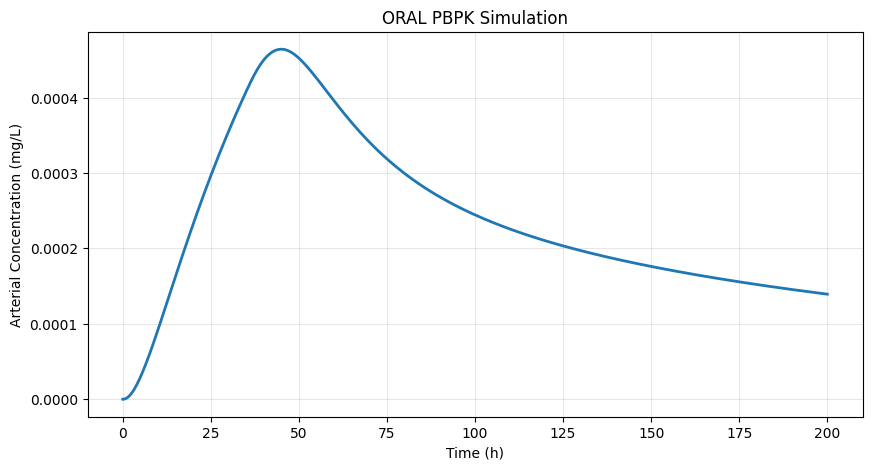

--- Results for User_Defined_Drug ---
Cmax: 0.0005 mg/L
AUC: 0.05 mg*h/L
Bioavailability: 0.23%
Fu: 0.031102630165687494
logP/logD: 4.2116000000000025
T1/2: 91.05809789642053 hrs

--- Tissue Exposure Summary (fu=0.0311) ---


/tmp/ipykernel_2030/408470927.py:369: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "AUC_Total_mghL": np.trapz(conc_total, t_eval),
/tmp/ipykernel_2030/408470927.py:371: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "AUC_Unbound_uMh": np.trapz(conc_unbound_uM, t_eval),


,Tissue,Cmax_Total_mgL,AUC_Total_mghL,Cmax_Unbound_uM,AUC_Unbound_uMh,Average_Unbound_uM
0,Plasma,0.000,0.048,0.000,0.002,0.000
1,Liver,0.124,10.582,0.005,0.467,0.002
2,Kidney,0.045,4.655,0.002,0.205,0.001
3,Stomach,0.638,48.677,0.028,2.148,0.011
4,Duodenum,0.233,16.071,0.010,0.709,0.004
5,Jejunum,0.255,16.409,0.011,0.724,0.004
6,Ileum,0.364,21.537,0.016,0.950,0.005
7,Muscle,0.017,2.589,0.001,0.114,0.001
8,Adipose,0.025,2.805,0.001,0.124,0.001
9,Brain,0.119,15.932,0.005,0.703,0.004


File saved as: Exposure_User_Defined_Drug.csv


In [37]:
#@title pyPBPK

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Tissue Composition Data (unchanged)
tissue_composition = {
    "liver":    {"f_w": 0.72, "f_nl": 0.02, "f_ph": 0.025, "f_p": 0.18, "pH": 7.2},
    "muscle":   {"f_w": 0.76, "f_nl": 0.01, "f_ph": 0.01,  "f_p": 0.18, "pH": 7.0},
    "adipose":  {"f_w": 0.15, "f_nl": 0.79, "f_ph": 0.002, "f_p": 0.04, "pH": 7.4},
    "brain":    {"f_w": 0.77, "f_nl": 0.05, "f_ph": 0.04,  "f_p": 0.10, "pH": 7.1},
    "kidney":   {"f_w": 0.77, "f_nl": 0.01, "f_ph": 0.02,  "f_p": 0.18, "pH": 7.2},
    "stomach":  {"f_w": 0.72, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.18, "pH": 7.2},
    "duodenum": {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
    "jejunum":  {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
    "ileum":    {"f_w": 0.74, "f_nl": 0.02, "f_ph": 0.02,  "f_p": 0.16, "pH": 7.2},
}

# --- Simplified Partitioning (Neutral Molecule) ---
def kp_rodgers_rowland(drug, tissue_name):
    if tissue_name not in tissue_composition: return 1.2
    comp = tissue_composition[tissue_name]
    logP = drug["physchem"]["logP"]

    P = 10**logP
    ratio = 1.0 # Constant for neutral molecules

    return (comp["f_w"] * ratio) + (comp["f_nl"] * P) + (comp["f_ph"] * P * 0.3) + (comp["f_p"] * 0.05)


def calculate_effective_mw(base_mw, n_f=0, n_cl=0, n_br=0, n_i=0):
    halogens = {'F': 18.99, 'Cl': 35.45, 'Br': 79.90, 'I': 126.90}
    return base_mw + (n_f * halogens['F']) + (n_cl * halogens['Cl']) + \
           (n_br * halogens['Br']) + (n_i * halogens['I'])

def blood_to_plasma_ratio(logP):
    """
    Simple empirical approximation.
    PK-Sim typically ranges 0.8–1.4 for most drugs.
    """
    return max(0.6, 1.0 + 0.4 * logP)

def get_fixed_physiology(base_physiology, weight=70):
    phys = {"weight": weight}
    ratio = weight / 70
    phys["cardiac_output"] = base_physiology["cardiac_output"] * (ratio ** 0.75)
    phys["blood"] = {k: v * ratio for k, v in base_physiology["blood"].items()}
    phys["organs"] = {}
    total_frac = sum(p["Q_frac"] for p in base_physiology["organs"].values() if p["Q_frac"] is not None)

    for organ, props in base_physiology["organs"].items():
        phys["organs"][organ] = props.copy()
        phys["organs"][organ]["V"] *= ratio
        if props.get("Q_frac") is not None:
            phys["organs"][organ]["Q"] = phys["cardiac_output"] * (props["Q_frac"] / total_frac)

    phys["organs"]["rest"]["Q"] = phys["cardiac_output"] - sum(o.get("Q", 0) for o in phys["organs"].values() if "Q" in o)
    return phys

def calculate_half_life(t, c):
    """Estimates half-life from the terminal elimination phase."""
    try:
        max_idx = np.argmax(c)
        # Look at the curve after Cmax
        t_post_cmax = t[max_idx:]
        c_post_cmax = c[max_idx:]

        # Only take points where concentration is significant (above 10% of Cmax)
        mask = c_post_cmax > (np.max(c) * 0.1)
        if sum(mask) < 2: return np.nan

        # Linear regression on log-transformed data: ln(C) = -ke * t + ln(C0)
        slope, intercept = np.polyfit(t_post_cmax[mask], np.log(c_post_cmax[mask] + 1e-9), 1)
        ke = -slope
        if ke <= 0: return np.nan
        return np.log(2) / ke
    except:
        return np.nan

#ODE System ---

physiology_base = {
    "cardiac_output": 420,
    "organs": {
        "liver":   {"V": 1.8, "Q_frac": 0.25}, "kidney":  {"V": 0.31, "Q_frac": 0.195},
        "stomach": {"V": 0.5, "Q_frac": 0.01}, "duodenum":{"V": 0.3, "Q_frac": 0.015},
        "jejunum": {"V": 0.6, "Q_frac": 0.035}, "ileum":   {"V": 0.6, "Q_frac": 0.03},
        "muscle":  {"V": 29,  "Q_frac": 0.145}, "adipose": {"V": 18,  "Q_frac": 0.05},
        "brain":   {"V": 1.4, "Q_frac": 0.08},  "rest":    {"V": 15,  "Q_frac": None}
    },
    "blood": {"V_art": 1.5, "V_ven": 3.0}
}

state_names = ["stomach_lumen", "duodenum_lumen", "jejunum_lumen", "ileum_lumen",
               "liver", "kidney", "stomach", "duodenum", "jejunum", "ileum",
               "muscle", "adipose", "brain", "rest", "arterial", "venous", "cm_absorbed"]
state_index = {name: i for i, name in enumerate(state_names)}
GI_segments = ["stomach", "duodenum", "jejunum", "ileum"]
GI_LUMEN_VOLUMES = {"stomach": 0.15, "duodenum": 0.05, "jejunum": 0.13, "ileum": 0.18}

def solve_multi_dose(pbpk_ode, y0, phys, drug, t_eval, dose_times, route):
    """
    Handles repeated dosing (oral or IV) by restarting the ODE between doses.
    """
    y_current = y0.copy()
    full_t = []
    full_y = []

    t_end = t_eval[-1]
    dose_times = sorted([t for t in dose_times if t < t_end]) + [t_end]

    for i in range(len(dose_times) - 1):
        t_start = dose_times[i]
        t_next = dose_times[i + 1]

        # ---- Administer dose ----
        if i > 0 or t_start == 0:
            if route == "oral":
                y_current[state_index["stomach_lumen"]] += drug["dose_mg"]
            elif route == "iv":
                y_current[state_index["venous"]] += drug["dose_mg"]

        t_span = [t_start, t_next]
        t_seg = t_eval[(t_eval >= t_start) & (t_eval <= t_next)]

        if len(t_seg) > 0:
            sol = solve_ivp(
                pbpk_ode,
                t_span,
                y_current,
                t_eval=t_seg,
                args=(phys, drug),
                method="LSODA"
            )

            full_t.extend(sol.t)
            full_y.append(sol.y)
            y_current = sol.y[:, -1]

    return np.hstack(full_y)

def pbpk_ode(t, y, phys, drug):

    dydt = np.zeros(len(state_names))

    Rbp = drug["Rbp"]
    C_art = (y[state_index["arterial"]] / phys["blood"]["V_art"]) / Rbp
    C_ven = (y[state_index["venous"]] / phys["blood"]["V_ven"]) / Rbp

    CL_liver = (drug["CL_liver_ml_min_kg"] * phys["weight"] * 60) / 1000
    CL_kidney = (drug["CL_kidney_ml_min_kg"] * phys["weight"] * 60) / 1000

    portal_flow_mass = 0.0
    T_rates = {"stomach": 0.2, "distal": 2.0}

    # --- GI SEGMENTS ---
    for i, seg in enumerate(GI_segments):

        l_idx = state_index[seg + "_lumen"]
        t_idx = state_index[seg]
        V_lum = GI_LUMEN_VOLUMES[seg]

        A_dissolved = min(y[l_idx], drug["solubility_mg_L"] * V_lum)
        abs_rate = drug["KA"] * A_dissolved

        out_rate = T_rates["stomach"] if seg == "stomach" else T_rates["distal"]
        in_flow = 0.0 if i == 0 else (
            T_rates["stomach"] if i == 1 else T_rates["distal"]
        ) * y[state_index[GI_segments[i-1] + "_lumen"]]

        dydt[l_idx] = in_flow - abs_rate - (out_rate * y[l_idx])
        dydt[state_index["cm_absorbed"]] += abs_rate

        Q = phys["organs"][seg]["Q"]
        V = phys["organs"][seg]["V"]
        Kp = drug["Kp_map"][seg]

        C_ven_seg = (y[t_idx] / V) / Kp
        dydt[t_idx] = abs_rate + Q * (C_art - C_ven_seg)

        portal_flow_mass += Q * C_ven_seg

    # --- SYSTEMIC ORGANS ---
    venous_return = 0.0

    for organ in ["liver", "kidney", "muscle", "adipose", "brain", "rest"]:

        o_idx = state_index[organ]
        Q = phys["organs"][organ]["Q"]
        V = phys["organs"][organ]["V"]
        Kp = drug["Kp_map"][organ]

        C_org = y[o_idx] / V
        C_ven_org = C_org / Kp

        if organ == "liver":

            Q_liver = phys["organs"]["liver"]["Q"]
            Q_portal = sum(phys["organs"][s]["Q"] for s in GI_segments)
            Q_total_liver = Q_liver + Q_portal

            E_h = CL_liver / (Q_total_liver + CL_liver)
            elim = Q_total_liver * E_h * C_ven_org

            dydt[o_idx] = (
                (Q_liver * C_art)
                + portal_flow_mass
                - (Q_total_liver * C_ven_org)
                - elim
            )

            venous_return += Q_total_liver * C_ven_org

        elif organ == "kidney":

            # Flow-limited renal elimination
            elim = CL_kidney * C_ven_org
            dydt[o_idx] = Q * (C_art - C_ven_org) - elim

            venous_return += Q * C_ven_org

        else:

            dydt[o_idx] = Q * (C_art - C_ven_org)
            venous_return += Q * C_ven_org

    # --- BLOOD ---
    dydt[state_index["venous"]] = venous_return - phys["cardiac_output"] * C_ven
    dydt[state_index["arterial"]] = phys["cardiac_output"] * (C_ven - C_art)

    return dydt

parameter_mode = "Generate from SMILES"

# Hybrid SMILES ADMET Parameter Generation
if parameter_mode == "Generate from SMILES":
    import numpy as np
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None: raise ValueError("Invalid SMILES")

    # Basic RDKit descriptors
    mw_base = Descriptors.MolWt(mol)
    logP = Crippen.MolLogP(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    rotb = rdMolDescriptors.CalcNumRotatableBonds(mol)
    aromatic_atoms = sum(a.GetIsAromatic() for a in mol.GetAtoms())
    aromatic_fraction = aromatic_atoms / max(1, mol.GetNumHeavyAtoms())

    lipophilicity = logP

    # ESOL Solubility & Caco-2 Permeability
    logS = (0.16 - 0.63 * lipophilicity - 0.0062 * mw_base + 0.066 * rotb - 0.74 * aromatic_fraction)
    solubility = max((10**logS) * mw_base * 1000, 0.001)

    log10_peff = (-3.5 + 0.18 * lipophilicity - 0.01 * tpsa + 0.002 * rotb)
    permeability_keff = (10**log10_peff) * 60

    # --- USE PROVIDED FU ---
    # final_fu should be the variable name from your Ensemble cell
    fraction_unbound = final_fu

    # Intrinsic clearance (scaling factors)
    CLint = 10**(0.5 * lipophilicity - 1.2)
    hepatic_flow = 20
    liver_clearance = (hepatic_flow * CLint / (hepatic_flow + CLint))
    renal_clearance = 0.1 + 0.5 * fraction_unbound

    # Clamp and Print
    solubility = float(np.clip(solubility, 0.001, 500000))
    liver_clearance = float(np.clip(liver_clearance, 0.01, 25))

    print(f"\nPredicted ADMET (Using Boltz-2/NN Fu: {fraction_unbound:.4f})")
    print(f"logP: {lipophilicity:.2f} | Solubility: {solubility:.2f} mg/L")

# --- Continue Setup & ODE Execution ---
eff_mw = mw_base
phys = get_fixed_physiology(physiology_base, individual_weight) # Ensure individual_weight is defined
dose_mg = dose_mg_per_kg * individual_weight # Defined globally here to fix the NameError
# Calculate how many doses actually fit into your simulation window
if dose_interval > 0:
    num_doses = int(simulation_time_hr // dose_interval)
    # Ensure at least 1 dose is given
    num_doses = max(1, num_doses)
    dose_times = [dose_interval * i for i in range(num_doses)]
else:
    dose_times = [0]
permeability_ka = (2 * permeability_keff / 1.5) * 60

drug_input = {
    "name": "User_Defined_Drug",
    "physchem": {"logP": lipophilicity},
    "KA": permeability_ka,
    "solubility_mg_L": solubility,
    "CL_liver_ml_min_kg": liver_clearance,
    "CL_kidney_ml_min_kg": renal_clearance,
    "fu": fraction_unbound,
    "MW_eff": eff_mw,
    "dose_mg": dose_mg,
    "dose_times": dose_times,
    "route": route
}

drug_input["Kp_map"] = {org: kp_rodgers_rowland(drug_input, org) for org in phys["organs"]}
drug_input["Rbp"] = blood_to_plasma_ratio(lipophilicity)

# --- Run Simulation ---
t_eval = np.linspace(0, simulation_time_hr, 500)
y0 = np.zeros(len(state_names))

if repeat_doses:
    Y = solve_multi_dose(pbpk_ode, y0, phys, drug_input, t_eval, dose_times, route)
else:
    # This now works because dose_mg is defined above
    if route == "oral":
        y0[state_index["stomach_lumen"]] = dose_mg
    else:
        y0[state_index["venous"]] = dose_mg

    sol = solve_ivp(pbpk_ode, [0, simulation_time_hr], y0, args=(phys, drug_input), t_eval=t_eval, method="LSODA")
    Y = sol.y


# PK Output
conc = Y[state_index["arterial"]] / phys["blood"]["V_art"]
Cmax = np.max(conc)
AUC = np.trapz(conc, t_eval)
total_dose = dose_mg * len(dose_times)
F_abs = Y[state_index["cm_absorbed"]][-1] / total_dose
thalf_val = calculate_half_life(t_eval, conc)


# Plot
plt.figure(figsize=(10,5))
plt.plot(t_eval, conc, linewidth=2)
plt.xlabel("Time (h)")
plt.ylabel("Arterial Concentration (mg/L)")
plt.title(f"{route.upper()} PBPK Simulation")
plt.grid(alpha=0.3)
plt.show()

# Results
print(f"--- Results for {drug_input['name']} ---")
print(f"Cmax: {Cmax:.4f} mg/L")
print(f"AUC: {AUC:.2f} mg*h/L")
print(f"Bioavailability: {F_abs:.2%}")
print(f"Fu: {fraction_unbound}")
print(f"logP/logD: {lipophilicity}")
print(f"T1/2: {thalf_val} hrs")

# --- Tissue Specific Exposure Analysis ---
fu = drug_input["fu"]
MW = drug_input["MW_eff"]
results = []

# Helper to process and append exposure data
def add_exposure(name, amount_array, volume):
    conc_total = amount_array / volume
    # Unbound concentration in µM: (mg/L * fu / MW) * 1000
    conc_unbound_uM = (conc_total * fu / MW) * 1000

    results.append({
        "Tissue": name,
        "Cmax_Total_mgL": np.max(conc_total),
        "AUC_Total_mghL": np.trapz(conc_total, t_eval),
        "Cmax_Unbound_uM": np.max(conc_unbound_uM),
        "AUC_Unbound_uMh": np.trapz(conc_unbound_uM, t_eval),
        "Average_Unbound_uM": np.mean(conc_unbound_uM)
    })

# 1. Process Plasma (Arterial)
add_exposure("Plasma", Y[state_index["arterial"]], phys["blood"]["V_art"])

# 2. Process all Organs
for organ, props in phys["organs"].items():
    if organ in state_index:
        add_exposure(organ.capitalize(), Y[state_index[organ]], props["V"])

# --- Finalize and Export ---
df_exposure = pd.DataFrame(results)
output_file = f"Exposure_{drug_input['name']}.csv"
df_exposure.to_csv(output_file, index=False)

# Display results
print(f"\n--- Tissue Exposure Summary (fu={fu:.4f}) ---")
display(df_exposure.round(3))
print(f"File saved as: {output_file}")


--- AOP Risk Summary (Reference: Liver) ---


,Target,AOP,Cmax_u (µM),IC50 (µM),Hazard_Ratio,Risk
8,ALDOA,Glycolysis,0.005,0.000,36.6451,HIGH
6,CYP2D6,Metabolism,0.005,0.001,8.3045,HIGH
3,APEX1,DNA Damage,0.005,0.005,1.2100,HIGH
0,PolH,DNA Repair,0.005,0.005,1.0869,HIGH
2,PolB,DNA Repair,0.005,0.009,0.5805,Low
7,CYP3A4,DDI Risk,0.005,0.010,0.5303,Low
5,KDM4E,Epigenetic,0.005,0.015,0.3614,Low
1,NFE2L2,Oxidative Stress,0.005,0.027,0.2030,Low
9,KDM4A,Chromatin,0.005,0.031,0.1752,Low
4,TDP1,DNA Break Repair,0.005,0.043,0.1266,Low


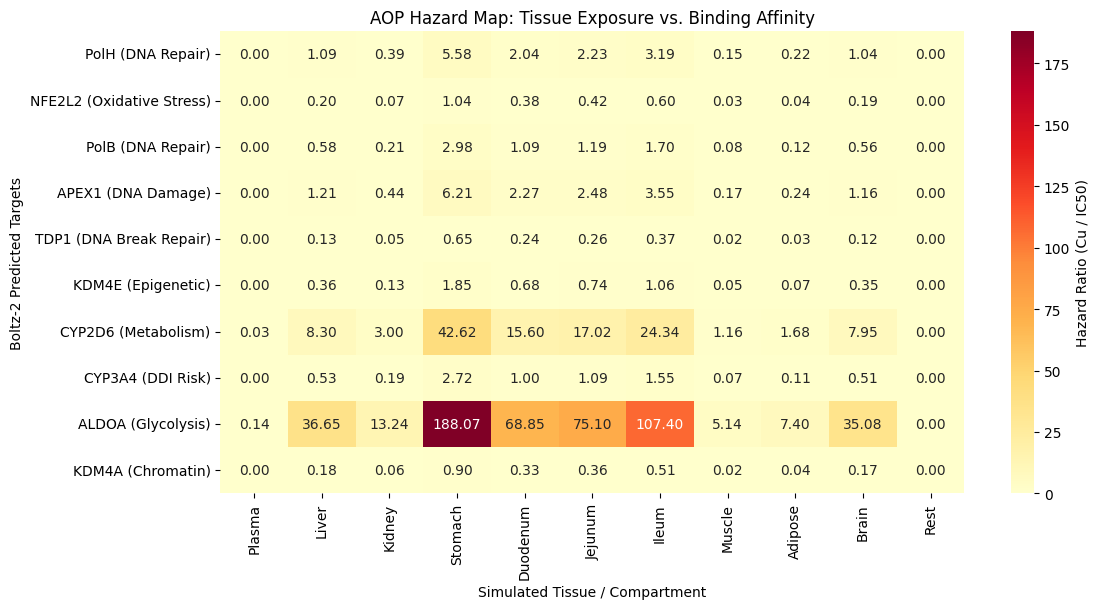

In [42]:
#@title AOP Integration & Hazard Prediction
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def generate_aop_heatmap(exposure_df, boltz_df):
    """
    Creates a simplified risk table and a heatmap of Hazard Ratios
    (Tissue Concentration / Predicted IC50) across all modeled organs.
    """
    # 1. Map Proteins to AOPs
    aop_map = {
        "PolH": "DNA Repair", "NFE2L2": "Oxidative Stress", "PolB": "DNA Repair",
        "APEX1": "DNA Damage", "TDP1": "DNA Break Repair", "KDM4E": "Epigenetic",
        "CYP2D6": "Metabolism", "CYP3A4": "DDI Risk", "ALDOA": "Glycolysis", "KDM4A": "Chromatin"
    }

    # 2. Prepare Simplified Summary (using Liver as default reference)
    summary_data = []
    heatmap_matrix = []

    # Get list of tissues from PBPK output (excluding 'cm_absorbed' if present)
    tissues = exposure_df['Tissue'].unique()

    for _, b_row in boltz_df.iterrows():
        p_id = b_row['id']
        # IC50 (µM) = 10^(6 - pIC50)
        ic50_uM = 10**(6 - b_row['boltz_pic50'])

        # Calculate Hazard Ratios for every tissue for the Heatmap
        tissue_ratios = []
        for tissue in tissues:
            cmax_u = exposure_df.loc[exposure_df['Tissue'] == tissue, 'Cmax_Unbound_uM'].values[0]
            ratio = cmax_u / ic50_uM
            tissue_ratios.append(ratio)

        heatmap_matrix.append(tissue_ratios)

        # Populate the simplified summary table (using Plasma/Liver for the row)
        ref_tissue = "Liver" if "Liver" in tissues else "Plasma"
        ref_cmax = exposure_df.loc[exposure_df['Tissue'] == ref_tissue, 'Cmax_Unbound_uM'].values[0]

        summary_data.append({
            "Target": p_id,
            "AOP": aop_map.get(p_id, "Other"),
            "Cmax_u (µM)": round(ref_cmax, 3),
            "IC50 (µM)": round(ic50_uM, 3),
            "Hazard_Ratio": round(ref_cmax / ic50_uM, 4),
            "Risk": "HIGH" if (ref_cmax / ic50_uM) > 1.0 else "Low"
        })

    # 3. Display Simplified Table
    df_summary = pd.DataFrame(summary_data).sort_values("Hazard_Ratio", ascending=False)
    print(f"\n--- AOP Risk Summary (Reference: {ref_tissue}) ---")
    display(df_summary)

    # 4. Generate Heatmap
    plt.figure(figsize=(12, 6))
    df_heatmap = pd.DataFrame(heatmap_matrix, index=[f"{r['id']} ({aop_map.get(r['id'], '')})" for _, r in boltz_df.iterrows()], columns=tissues)

    # Use log scale for colors if ratios vary wildly, otherwise standard
    sns.heatmap(df_heatmap, annot=True, cmap="YlOrRd", fmt=".2f", cbar_kws={'label': 'Hazard Ratio (Cu / IC50)'})
    plt.title("AOP Hazard Map: Tissue Exposure vs. Binding Affinity")
    plt.xlabel("Simulated Tissue / Compartment")
    plt.ylabel("Boltz-2 Predicted Targets")
    plt.show()

# Execute
if 'inference_df' in locals() and 'df_exposure' in locals():
    generate_aop_heatmap(df_exposure, inference_df)
else:
    print("Run Boltz-2 and PBPK cells first.")